In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

from tp7.tp7 import Tape7
from srfs.srfs import SRFS
import scipy.integrate as integrate
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

## Experiments to do
1. testing with just the bands and no integrated sw/lw
    1. do EDA/other things for testing which bands are needed and unneeded
2. testing with just the integrated radiances and no bands
3. experiment with a cloud and no cloud model
4. experiment with scene encoding and without
    1. ask peter when we know the scene, if we know the scene ahead of time we can encode the scenes

## EDA

In [7]:
def modtran_data_files(path: str) -> list:
    files = [path + "/" + file for file in os.listdir(path) if file.endswith(".tp7")]
    return files

a00_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA00")
a41_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA41")
a60_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA60")
a75_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA75")
a85_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA85")

srf = SRFS("./data/libera_srfs_20241017.csv")
tot_wvln = srf.srf_vals['wavelength [um]']
sw_srf = srf.srf_vals[' sw srf']
lw_srf = srf.srf_vals[' lw srf']

viirs_rads_indxs = {'M1': [1469, 1701],
             'M2': [1648, 1849],
             'M3': [1873, 2039],
             'M4': [2131, 2260],
             'I1': [2231, 2601],
             'M5': [2467, 2559],
             'DNB': [667, 3090],
             'M6': [2621, 2696],
             'I2': [2790, 2893],
             'M7': [2790, 2893],
             'M8': [3181, 3206],
             'M9': [3264, 3284],
             'I3': [3355, 3401],
             'M10': [3355, 3401],
             'M11': [3546, 3565],
             'I4': [3703, 3757],
             'M12': [3716, 3742],
             'M13': [3744, 3762],
             'M14': [3879, 3887],
             'M15': [3898, 3914],
             'I5': [3896, 3925],
             'M16': [3910, 3922]}

In [8]:
def plot_radiance(rads, title, runnum, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(rads[runnum, 0, :], rads[runnum, s_or_l, :], 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 2:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)

In [9]:
def plot_integrated_radiance(rads, title, idx, wvs, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(wvs, rads[idx, :], 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 2:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)

In [10]:
def viirs_band_integration(tp7_data: Tape7, rad_indxs: dict):
    for idx, run in enumerate(tp7_data.rads):
        for band, rng in rad_indxs.items():
            y_vals = run[1][rng[0]: rng[1] + 1]
            x_vals = run[0][rng[0]: rng[1] + 1]
            integrated = integrate.simpson(y=y_vals, x=x_vals)
            tp7_data.describer_df.loc[idx, band] = integrated

In [11]:
a00_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a00_files]
titles = [file.title for file in a00_data]
a00 = {title: file for title, file in zip(titles, a00_data)}

a41_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a41_files]
titles = [file.title for file in a41_data]
a41 = {title: file for title, file in zip(titles, a41_data)}

a60_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a60_files]
titles = [file.title for file in a60_data]
a60 = {title: file for title, file in zip(titles, a60_data)}

a75_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a75_files]
titles = [file.title for file in a75_data]
a75 = {title: file for title, file in zip(titles, a75_data)}

a85_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a85_files]
titles = [file.title for file in a85_data]
a85 = {title: file for title, file in zip(titles, a85_data)}

In [12]:
snow_data = [a00["Snow"], a41["Snow"], a60["Snow"], a75["Snow"], a85["Snow"]]
dc_data = [a00["Deep Convective Cloud"], a41["Deep Convective Cloud"], a60["Deep Convective Cloud"],
           a75["Deep Convective Cloud"], a85["Deep Convective Cloud"]]
land_data = [a00["Land"], a41["Land"], a60["Land"], a75["Land"], a85["Land"]]
clear_data = [a00["Clear Ocean"], a41["Clear Ocean"], a60["Clear Ocean"], a75["Clear Ocean"], a85["Clear Ocean"]]
cloudy_data = [a00["Cloudy Ocean"], a41["Cloudy Ocean"], a60["Cloudy Ocean"], a75["Cloudy Ocean"], a85["Cloudy Ocean"]]
[viirs_band_integration(data, viirs_rads_indxs) for data in snow_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in dc_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in land_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in clear_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in cloudy_data]

[None, None, None, None, None]

In [13]:
snow_dfs = [file.describer_df for file in snow_data]
snow_dataset = pd.concat(snow_dfs, axis=0)
land_dfs = [file.describer_df for file in land_data]
dc_dfs = [file.describer_df for file in dc_data]
cloud_dfs = [file.describer_df for file in cloudy_data]
clear_dfs = [file.describer_df for file in clear_data]
land_dataset = pd.concat(land_dfs, axis=0)
dc_dataset = pd.concat(dc_dfs, axis=0)
cloud_dataset = pd.concat(cloud_dfs, axis=0)
clear_dataset = pd.concat(clear_dfs, axis=0)

In [9]:
scene_map = {"Land": 0,
             "Snow": 1,
             "Clear Ocean": 2,
             "Cloudy Ocean": 3,
             "Deep Convective Cloud": 4}
map_scene = {value: key for key, value in scene_map.items()}
map_scene

{0: 'Land',
 1: 'Snow',
 2: 'Clear Ocean',
 3: 'Cloudy Ocean',
 4: 'Deep Convective Cloud'}

## Experiment 1
testing with all data, vs just bands vs just the integrated full wvs

In [10]:
a00

{'Snow': <tp7.tp7.Tape7 at 0x16ad892b0>,
 'Land': <tp7.tp7.Tape7 at 0x16bd1a000>,
 'Clear Ocean': <tp7.tp7.Tape7 at 0x34f9ea990>,
 'Cloudy Ocean': <tp7.tp7.Tape7 at 0x32d3291c0>,
 'Deep Convective Cloud': <tp7.tp7.Tape7 at 0x33ea1f4a0>}

In [11]:
a00_dataset = pd.concat([a00["Land"].describer_df, a00["Snow"].describer_df, a00["Clear Ocean"].describer_df, a00["Cloudy Ocean"].describer_df, a00["Deep Convective Cloud"].describer_df])
a00_dataset = a00_dataset.drop(columns=["Run #"])
a00_dataset.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
       'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object')

### All data

In [232]:
scaler = StandardScaler()
X = a00_dataset.drop(columns=["Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)"]).reset_index(drop=True)
y = a00_dataset.drop(columns=["Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                               'Shortwave Filtered Rads (Integrated)',
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

In [233]:
X.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
       'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object')

In [234]:
y.columns

Index(['Shortwave Unfiltered Rads (Integrated)', 'Longwave Unfiltered Rads (Integrated)'], dtype='object')

In [235]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=X["Scene"])

In [221]:
X_train["Scene"] = X_train["Scene"].map(scene_map)
# y_train["Scene"] = y_train["Scene"].map(scene_map)
X_test["Scene"] = X_test["Scene"].map(scene_map)
# y_test["Scene"] = y_test["Scene"].map(scene_map)

In [224]:
base_model = RandomForestRegressor(n_estimators=100, random_state=42)
model = MultiOutputRegressor(base_model)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')  # Separate MSE for each output
print(f"Mean Squared Errors: Shortwave={mse[0]}, Longwave={mse[1]}")

Mean Squared Errors: Shortwave=0.07121301653221314, Longwave=0.4088624560785732


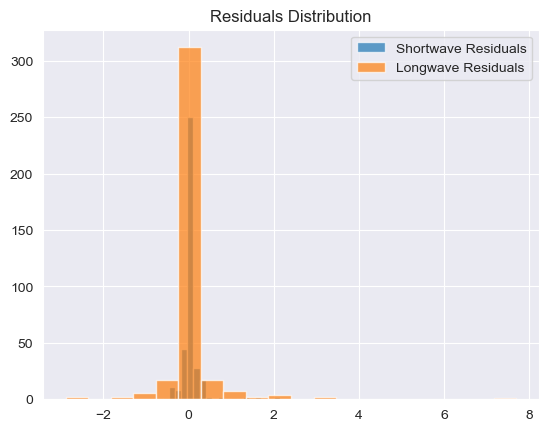

In [225]:
residuals_shortwave = y_test["Shortwave Unfiltered Rads (Integrated)"] - y_pred[:, 0]
residuals_longwave = y_test["Longwave Unfiltered Rads (Integrated)"] - y_pred[:, 1]

plt.hist(residuals_shortwave, bins=20, alpha=0.7, label="Shortwave Residuals")
plt.hist(residuals_longwave, bins=20, alpha=0.7, label="Longwave Residuals")
plt.legend()
plt.title("Residuals Distribution")
plt.show()

In [226]:
y_pred = model.predict(X_test)
mse_test = mean_squared_error(y_test, y_pred, multioutput="raw_values")
r2 = r2_score(y_test, y_pred, multioutput="variance_weighted")
print(f"MSE: Shortwave={mse_test[0]}, Longwave={mse_test[1]}")
print(f"R² Score: {r2}")

MSE: Shortwave=0.07121301653221314, Longwave=0.4088624560785732
R² Score: 0.9999611428792643


In [227]:
X_check = X
X_check["Scene"] = X_check["Scene"].map(scene_map)
y_check = y

In [229]:
scores = cross_val_score(model, X_check, y_check, cv=5, scoring="neg_mean_squared_error")
print(f"Cross-validated MSE: {scores}")

Cross-validated MSE: [-5.34846461e+01 -1.14706691e+01 -6.15469352e+01 -1.82819812e-10
 -2.49767577e+02]


### Just bands

In [200]:
X = a00_dataset.drop(columns=['Shortwave Unfiltered Rads (Integrated)', 'Longwave Unfiltered Rads (Integrated)',
                                'Shortwave Filtered Rads (Integrated)','Longwave Filtered Rads (Integrated)']).reset_index(drop=True)
y = a00_dataset.drop(columns=["Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                               'Shortwave Filtered Rads (Integrated)',
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

In [201]:
X.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
       'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object')

In [202]:
y.columns

Index(['Shortwave Unfiltered Rads (Integrated)', 'Longwave Unfiltered Rads (Integrated)'], dtype='object')

In [203]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=X["Scene"]
)
X_train["Scene"] = X_train["Scene"].map(scene_map)
# y_train["Scene"] = y_train["Scene"].map(scene_map)
X_test["Scene"] = X_test["Scene"].map(scene_map)
# y_test["Scene"] = y_test["Scene"].map(scene_map)

In [204]:
base_model = RandomForestRegressor(n_estimators=100, random_state=42)
model = MultiOutputRegressor(base_model)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')  # Separate MSE for each output
print(f"Mean Squared Errors: Shortwave={mse[0]}, Longwave={mse[1]}")

Mean Squared Errors: Shortwave=0.14163770699107972, Longwave=0.8370758114390838


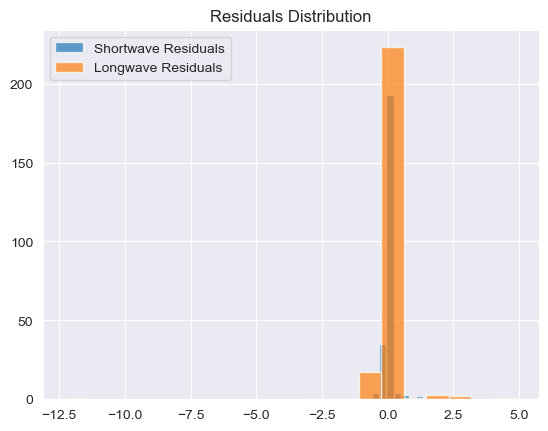

In [205]:
residuals_shortwave = y_test["Shortwave Unfiltered Rads (Integrated)"] - y_pred[:, 0]
residuals_longwave = y_test["Longwave Unfiltered Rads (Integrated)"] - y_pred[:, 1]

plt.hist(residuals_shortwave, bins=20, alpha=0.7, label="Shortwave Residuals")
plt.hist(residuals_longwave, bins=20, alpha=0.7, label="Longwave Residuals")
plt.legend()
plt.title("Residuals Distribution")
plt.show()

In [167]:
y["Shortwave Unfiltered Rads (Integrated)"].describe()

count    1.239000e+03
mean     9.768485e+01
std      1.111522e+02
min      3.896676e-08
25%      1.240382e-06
50%      7.554133e+01
75%      1.568304e+02
max      3.528094e+02
Name: Shortwave Unfiltered Rads (Integrated), dtype: float64

In [178]:
X_check = X
X_check["Scene"] = X_check["Scene"].map(scene_map)
y_check = y
# y_check["Scene"] = y_check["Scene"].map(scene_map)

In [179]:
X_check.columns, y_check.columns

(Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'M1', 'M2', 'M3', 'M4', 'I1',
        'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
        'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
       dtype='object'),
 Index(['Shortwave Unfiltered Rads (Integrated)', 'Longwave Unfiltered Rads (Integrated)'], dtype='object'))

In [180]:
scores = cross_val_score(model, X_check, y_check, cv=5, scoring="neg_mean_squared_error")
print(f"Cross-validated MSE: {-scores.mean()}")

Cross-validated MSE: 58.74152285574513


### Experiment 2
using all the scenes together and the SZA as the "class"

In [18]:
a41

{'Snow': <tp7.tp7.Tape7 at 0x150a46990>,
 'Land': <tp7.tp7.Tape7 at 0x16c0a5580>,
 'Clear Ocean': <tp7.tp7.Tape7 at 0x16c0a55e0>,
 'Deep Convective Cloud': <tp7.tp7.Tape7 at 0x151d44410>,
 'Cloudy Ocean': <tp7.tp7.Tape7 at 0x151f5c230>}

In [19]:
snow41 = a00["Deep Convective Cloud"]
snow41.integrated_rads.shape, snow41.rads.shape

((4, 63), (63, 3, 4000))

In [15]:
dc41 = a41["Deep Convective Cloud"]

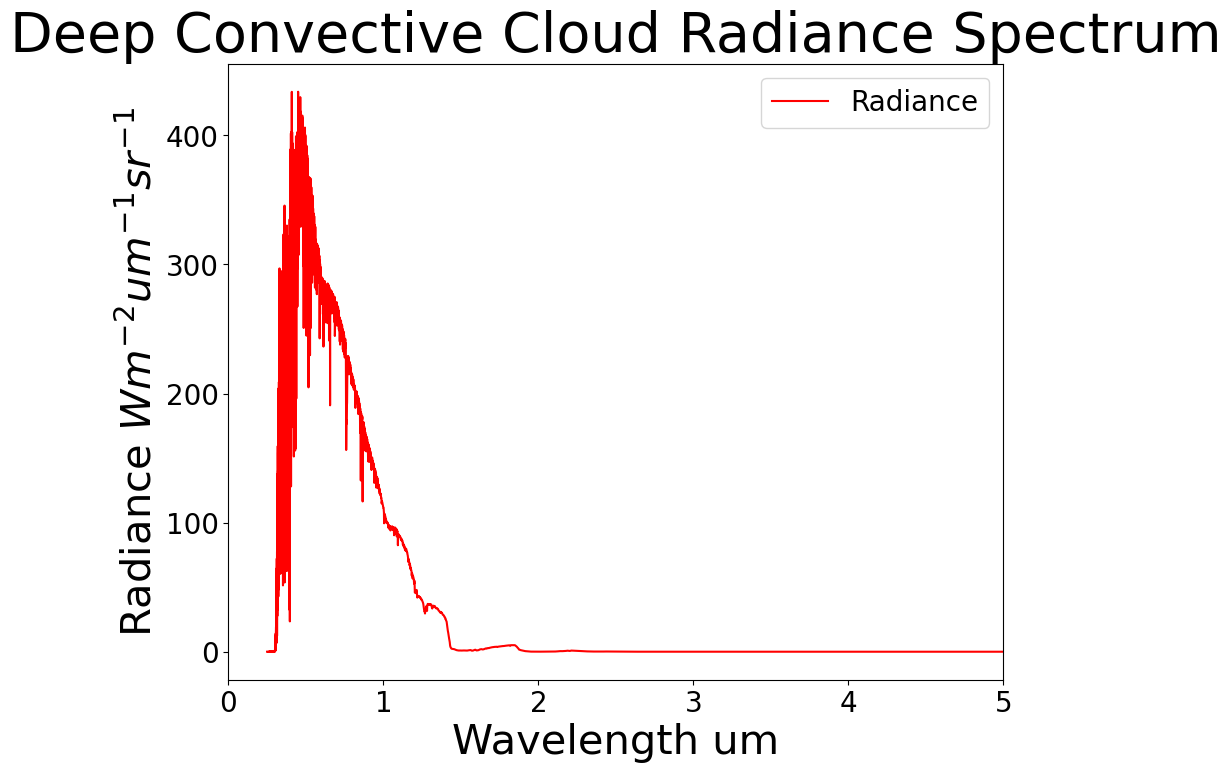

In [16]:
plot_radiance(dc41.rads, dc41.title, 0, 1)

In [21]:
snow41.integrated_rads[2].shape, snow41.rads[0, 0, :].shape# (rads, title, idx, wvs, s_or_l=1)

((63,), (4000,))

In [22]:
temp_wv, temp_sw = snow41.rads[0, 0, :], snow41.rads[0, 1, :]
interpolated_sw_srf = np.interp(x=temp_wv, xp=tot_wvln, fp=sw_srf)
interpolated_sw_srf.shape

(4000,)

In [23]:
temp_sw_interp = temp_sw * interpolated_sw_srf
temp_sw.shape

(4000,)

(0.0, 5.0)

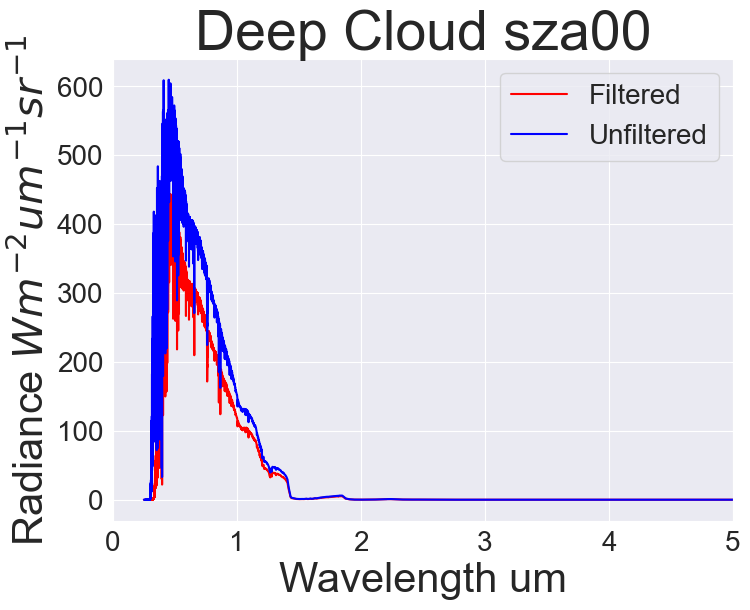

In [30]:
figure = plt.figure(2, figsize=(8,6))
ax = plt.axes()
ax.plot(temp_wv, temp_sw_interp, 'r-', label='Filtered')
ax.plot(temp_wv, temp_sw, 'b-', label='Unfiltered')
ax.legend(prop={"size":20})
plt.title("Deep Cloud sza00", fontsize=40)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Wavelength um', fontsize=30)
plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
plt.xlim(0,5)

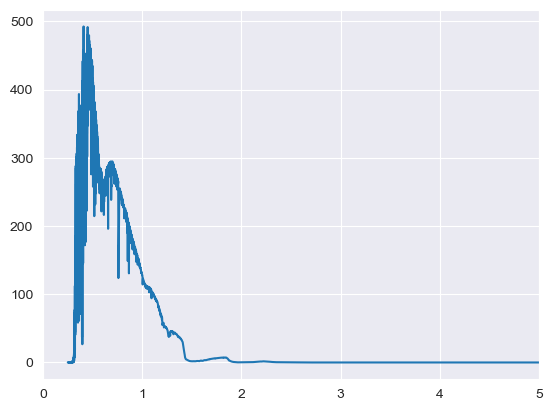

In [25]:
plt.plot(snow41.rads[0, 0, :], snow41.rads[-1, 1, :])
plt.xlim(0,5)
plt.show()

### Snow experiment
Without using the SZA as a class and just as an input

In [17]:
snow_data

In [20]:
# snow_dataset = snow_dataset.drop(columns=["Scene"])
# snow_dataset.columns

Index(['SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
       'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object')

In [36]:
X_snow = snow_dataset.drop(columns=["Scene", "Run #", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)"]).reset_index(drop=True)
y_snow = snow_dataset.drop(columns=["Scene", "Run #", 'SZA', 'VZA', 'RAZ', 'Cloud',
                               'Shortwave Filtered Rads (Integrated)',
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)
X_snow

,SZA,VZA,RAZ,Cloud,Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),M1,M2,M3,M4,...,I3,M10,M11,I4,M12,M13,M14,M15,I5,M16
0,0.000,0.000,0.0,0,1.233818e-06,5.401733e-10,3.698819e-08,4.805188e-08,6.142518e-08,6.851154e-08,...,2.061115e-08,2.061115e-08,1.294771e-08,1.012036e-09,5.960777e-10,2.082543e-10,6.440607e-11,1.646966e-10,4.000026e-10,2.710446e-10
1,0.000,0.000,0.0,1,1.243242e-06,3.165444e-09,3.692902e-08,4.814126e-08,6.178791e-08,6.915123e-08,...,2.117097e-08,2.117097e-08,1.320502e-08,3.229515e-09,1.850903e-09,9.398765e-10,2.377036e-10,2.072401e-10,5.199736e-10,3.242782e-10
2,0.000,0.000,0.0,1,1.177596e-06,5.126559e-10,3.751921e-08,4.901099e-08,6.306054e-08,7.078298e-08,...,1.204850e-08,1.204850e-08,9.362810e-09,7.682494e-10,4.208298e-10,1.542069e-10,6.116022e-11,1.349419e-10,3.847836e-10,2.757378e-10
3,0.000,0.000,0.0,1,2.209365e-06,6.147627e-08,3.733525e-08,4.878219e-08,6.292744e-08,7.081160e-08,...,1.587840e-07,1.587840e-07,5.620044e-08,8.617688e-08,4.761121e-08,2.589598e-08,9.197222e-09,8.441875e-09,1.234543e-08,4.586360e-09
4,0.000,0.000,0.0,1,1.728870e-06,2.828023e-08,3.739837e-08,4.882870e-08,6.274427e-08,7.005855e-08,...,1.339339e-07,1.339339e-07,5.706589e-08,8.934601e-08,5.176274e-08,2.368786e-08,8.525046e-09,7.267995e-09,1.004057e-08,3.556194e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1570,83.928,89.947,172.5,0,2.273943e-07,1.706181e-10,1.315574e-08,1.678334e-08,1.943650e-08,1.423849e-08,...,3.443703e-09,3.443703e-09,5.301123e-10,3.511208e-10,2.286629e-10,4.215247e-11,1.173726e-11,8.405163e-11,1.437340e-10,9.936899e-11
1571,83.928,89.947,172.5,1,5.319460e-07,2.735265e-08,1.306697e-08,1.638462e-08,1.866564e-08,1.405865e-08,...,2.955183e-08,2.955183e-08,1.377672e-08,2.394832e-08,1.391585e-08,6.622763e-09,2.678546e-09,9.043345e-10,1.920534e-09,1.128648e-09
1572,83.928,89.947,172.5,1,3.543358e-07,4.524527e-10,1.331599e-08,1.712982e-08,2.016228e-08,1.531015e-08,...,1.414065e-08,1.414065e-08,6.461028e-09,8.114615e-10,5.561632e-10,6.800723e-11,4.869360e-11,1.995285e-10,4.595425e-10,3.719880e-10
1573,83.928,89.947,172.5,1,7.532011e-07,2.035356e-08,1.327817e-08,1.692780e-08,1.967271e-08,1.486676e-08,...,6.606078e-08,6.606078e-08,2.339958e-08,3.682691e-08,2.464897e-08,5.153296e-09,3.735382e-09,6.878763e-09,9.827696e-09,4.724706e-09


In [37]:
X_train_snow, X_test_snow, y_train_snow, y_test_snow = train_test_split(X_snow, y_snow, test_size=0.2, random_state=42)

In [43]:
y_test_snow

,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated)
1246,8.546243e-07,0.000416
813,1.478581e-06,0.000460
1173,8.779461e-07,0.000460
534,1.619076e-06,0.000477
514,1.620144e-06,0.000477
...,...,...
818,1.477884e-06,0.000460
1107,3.121317e-07,0.000486
1211,1.361076e-06,0.000417
1378,2.171285e-07,0.000464


In [39]:
base_model = RandomForestRegressor(n_estimators=100, random_state=42)
snow_model = MultiOutputRegressor(base_model)
snow_model.fit(X_train_snow, y_train_snow)
y_pred_snow = snow_model.predict(X_test_snow)
snow_mse = mean_squared_error(y_test_snow, y_pred_snow, multioutput='raw_values')  # Separate MSE for each output
print(f"Mean Squared Errors: Shortwave={snow_mse[0]}, Longwave={snow_mse[1]}")

Mean Squared Errors: Shortwave=1.0599944316480772e-15, Longwave=6.410458755556584e-13


In [46]:
tg_range = max(y_test_snow["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test_snow["Shortwave Unfiltered Rads (Integrated)"])
snow_rmse_percent = (1.0 - (snow_mse[0] / tg_range)) * 100
snow_rmse_percent
# min(y_test_snow["Shortwave Unfiltered Rads (Integrated)"]), max(y_test_snow["Shortwave Unfiltered Rads (Integrated)"])
# snow_mse

99.99999998601842

In [56]:
snow_scores = cross_val_score(snow_model, X_snow, y_snow, cv=5, scoring="neg_mean_squared_error")
print(f"Cross-validated MSE: {-snow_scores.mean()}", snow_scores)

Cross-validated MSE: 1.7858295540272075e-06 [-1.99296712e-06 -2.24893824e-07 -1.11076040e-06 -1.24739178e-06
 -4.35313464e-06]


In [47]:
land_dfs = [file.describer_df for file in land_data]
dc_dfs = [file.describer_df for file in dc_data]
cloud_dfs = [file.describer_df for file in cloudy_data]
clear_dfs = [file.describer_df for file in clear_data]

In [48]:
land_dataset = pd.concat(land_dfs, axis=0)
dc_dataset = pd.concat(dc_dfs, axis=0)
cloud_dataset = pd.concat(cloud_dfs, axis=0)
clear_dataset = pd.concat(clear_dfs, axis=0)

In [49]:
land_dataset.shape[0], dc_dataset.shape[0], cloud_dataset.shape[0], clear_dataset.shape[0]

(3150, 315, 420, 735)

In [50]:
X_land = land_dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)"]).reset_index(drop=True)
y_land = land_dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                               'Shortwave Filtered Rads (Integrated)',
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)
X_land

,SZA,VZA,RAZ,Cloud,Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),M1,M2,M3,M4,...,I3,M10,M11,I4,M12,M13,M14,M15,I5,M16
0,0.0,0.000,0.0,0,75.727145,0.016809,4.442415,4.988403,5.780654,5.849697,...,4.098689,4.098689,0.888305,0.537510,0.270949,0.142514,0.002908,0.003333,0.004053,0.001379
1,0.0,0.000,0.0,1,75.293403,0.003139,5.664711,6.258118,6.945489,6.671638,...,1.003400,1.003400,0.375608,0.015245,0.007734,0.003539,0.000123,0.000141,0.000334,0.000209
2,0.0,0.000,0.0,1,113.325768,0.002398,9.382707,10.438244,11.262057,10.280915,...,0.257322,0.257322,0.132324,0.006315,0.003205,0.001267,0.000097,0.000112,0.000304,0.000200
3,0.0,0.000,0.0,1,183.088022,0.021329,16.366327,18.485496,19.954956,17.804268,...,5.921798,5.921798,1.063389,0.406027,0.223714,0.116470,0.005231,0.003540,0.004254,0.000978
4,0.0,0.000,0.0,1,247.891967,0.029803,22.198565,25.244513,27.396480,24.593184,...,4.709992,4.709992,0.596189,0.237953,0.131297,0.059864,0.005415,0.005315,0.007217,0.002713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,75.0,79.914,172.5,0,45.187776,0.000783,6.271896,6.782332,6.382949,3.617978,...,0.640583,0.640583,0.050141,0.011677,0.008464,0.000769,0.000045,0.000242,0.000294,0.000123
3146,75.0,79.914,172.5,1,67.593585,0.005055,6.897108,7.562126,7.241062,4.285508,...,0.726219,0.726219,0.228376,0.015232,0.008511,0.002037,0.000189,0.000266,0.000737,0.000560
3147,75.0,79.914,172.5,1,68.522085,0.005233,7.114266,7.751719,7.372872,4.334716,...,0.679221,0.679221,0.206617,0.014323,0.007853,0.002099,0.000176,0.000258,0.000695,0.000525
3148,75.0,79.914,172.5,1,60.268627,0.003237,7.338484,8.099260,7.823770,4.563531,...,1.556655,1.556655,0.232907,0.052482,0.041133,0.003081,0.000493,0.001370,0.001621,0.000602


In [51]:
X_train_land, X_test_land, y_train_land, y_test_land = train_test_split(X_land, y_land, test_size=0.2, random_state=42)

In [52]:
land_model = MultiOutputRegressor(base_model)
land_model.fit(X_train_land, y_train_land)
y_pred_land = land_model.predict(X_test_land)
land_mse = mean_squared_error(y_test_land, y_pred_land, multioutput='raw_values')  # Separate MSE for each output
print(f"Mean Squared Errors: Shortwave={land_mse[0]}, Longwave={land_mse[1]}")

Mean Squared Errors: Shortwave=0.7401687061049165, Longwave=1.8126938240605868


In [53]:
tg_range_land = max(y_test_land["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test_land["Shortwave Unfiltered Rads (Integrated)"])
land_rmse_percent = (1.0 - (land_mse[0] / tg_range_land)) * 100
land_rmse_percent

99.8776275847532

In [59]:
tg_range_land = max(y_test_land["Longwave Unfiltered Rads (Integrated)"]) - min(y_test_land["Longwave Unfiltered Rads (Integrated)"])
land_rmse_percent = (1.0 - (land_mse[1] / tg_range_land)) * 100
land_rmse_percent

96.6631732117451

In [57]:
land_scores = cross_val_score(land_model, X_land, y_land, cv=5, scoring="neg_mean_squared_error")
print(f"Cross-validated MSE: {-land_scores.mean()}", land_scores)

Cross-validated MSE: 8.545036141658807 [-13.23806181  -2.48623619  -2.685819    -9.00001944 -15.31504428]


In [60]:
land_model2 = MultiOutputRegressor(LinearRegression())
land_model2.fit(X_train_land, y_train_land)
y_pred_land2 = land_model2.predict(X_test_land)
land_mse2 = mean_squared_error(y_test_land, y_pred_land2, multioutput='raw_values')  # Separate MSE for each output
print(f"Mean Squared Errors: Shortwave={land_mse2[0]}, Longwave={land_mse2[1]}")

Mean Squared Errors: Shortwave=0.0037801115908346937, Longwave=36.72001820800114


In [61]:
land_scores2 = cross_val_score(land_model2, X_land, y_land, cv=7, scoring="neg_mean_squared_error")
print(f"Cross-validated MSE: {-land_scores2.mean()}")

Cross-validated MSE: 3.7034221722118335


# Dc Experiment

In [106]:
X_dc = dc_dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)"]).reset_index(drop=True)
y_dc = dc_dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                               'Shortwave Filtered Rads (Integrated)',
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)
X_dc

,SZA,VZA,RAZ,Cloud,Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),M1,M2,M3,M4,...,I3,M10,M11,I4,M12,M13,M14,M15,I5,M16
0,0.000,0.00000,0.0,1,195.640424,0.002083,16.936833,19.160294,20.608176,17.949673,...,0.214285,0.214285,0.081215,0.004303,0.002150,0.000934,0.000067,0.000076,0.000200,0.000126
1,0.000,0.00000,0.0,1,194.542475,0.002054,16.895913,19.077547,20.527047,18.147227,...,0.206277,0.206277,0.078353,0.004280,0.002138,0.000926,0.000067,0.000075,0.000199,0.000126
2,0.000,0.00000,0.0,1,195.359351,0.002217,16.949803,19.115562,20.555415,18.277463,...,0.209257,0.209257,0.082809,0.004474,0.002286,0.000933,0.000069,0.000088,0.000224,0.000147
3,0.506,29.49001,7.5,1,189.100982,0.001356,16.438572,18.575901,19.937287,17.268393,...,0.184100,0.184100,0.072852,0.002620,0.001303,0.000552,0.000042,0.000048,0.000132,0.000085
4,0.506,29.49001,7.5,1,188.285108,0.001328,16.415525,18.516774,19.886436,17.491820,...,0.176151,0.176151,0.070001,0.002598,0.001292,0.000546,0.000042,0.000048,0.000132,0.000085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,76.998,79.91400,142.5,1,44.879454,0.001803,4.971779,5.213218,4.924760,3.165091,...,0.255377,0.255377,0.053450,0.003682,0.001889,0.000733,0.000050,0.000059,0.000147,0.000101
311,76.998,79.91400,142.5,1,46.139023,0.002402,5.198071,5.445902,5.125853,3.289294,...,0.266956,0.266956,0.062721,0.004462,0.002482,0.000768,0.000057,0.000105,0.000237,0.000179
312,75.000,79.91400,172.5,1,50.496875,0.001818,5.522118,5.789273,5.481981,3.523988,...,0.280318,0.280318,0.064809,0.003563,0.001828,0.000713,0.000047,0.000055,0.000137,0.000094
313,75.000,79.91400,172.5,1,51.509119,0.001746,5.781317,6.044311,5.703659,3.695349,...,0.263016,0.263016,0.060158,0.003492,0.001791,0.000696,0.000046,0.000055,0.000136,0.000093


In [107]:
X_train_dc, X_test_dc, y_train_dc, y_test_dc = train_test_split(X_dc, y_dc, test_size=0.2, random_state=42)

In [108]:
X_train_dc

,SZA,VZA,RAZ,Cloud,Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),M1,M2,M3,M4,...,I3,M10,M11,I4,M12,M13,M14,M15,I5,M16
221,74.629,44.12100,172.5,1,45.933346,0.001003,4.107451,4.531834,4.704739,3.826527,...,0.181437,0.181437,0.035665,0.001666,0.000909,0.000300,0.000023,0.000033,0.000080,0.000056
132,60.404,29.49001,37.5,1,87.299232,0.001982,7.469011,8.413493,8.959706,7.527801,...,0.206788,0.206788,0.058080,0.004127,0.002060,0.000886,0.000069,0.000077,0.000199,0.000126
155,59.303,44.12100,142.5,1,90.769831,0.001368,7.900829,8.825037,9.347503,8.001271,...,0.195486,0.195486,0.063121,0.002502,0.001292,0.000501,0.000038,0.000048,0.000125,0.000084
94,40.529,44.12100,172.5,1,139.203676,0.001450,12.117122,13.610017,14.520769,12.566495,...,0.209077,0.209077,0.076489,0.002746,0.001375,0.000574,0.000043,0.000048,0.000132,0.000086
245,75.500,79.91400,90.0,1,50.101533,0.004102,4.987041,5.363419,5.231122,3.529070,...,0.326350,0.326350,0.082812,0.009007,0.004764,0.001711,0.000129,0.000191,0.000453,0.000328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,50.000,79.91400,172.5,1,113.567499,0.002842,10.774557,11.813820,11.897960,8.612331,...,0.358188,0.358188,0.141118,0.005854,0.003020,0.001136,0.000078,0.000102,0.000268,0.000191
71,41.805,29.49001,37.5,1,138.816749,0.001965,11.929711,13.439436,14.405869,12.657526,...,0.207533,0.207533,0.075724,0.004039,0.002036,0.000845,0.000065,0.000077,0.000201,0.000131
106,40.210,58.50000,142.5,1,138.077479,0.001935,12.055664,13.522944,14.372709,12.289350,...,0.250954,0.250954,0.095707,0.003799,0.001901,0.000795,0.000058,0.000066,0.000181,0.000118
270,85.871,44.12100,7.5,1,16.000845,0.002531,1.399900,1.548007,1.553855,1.045650,...,0.180521,0.180521,0.030255,0.005769,0.002916,0.001200,0.000096,0.000106,0.000269,0.000173


In [109]:
y_train_dc

,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated)
221,62.911733,31.841511
132,119.329892,28.077120
155,124.355662,31.841518
94,190.892018,28.931466
245,68.693603,34.170285
...,...,...
188,155.524334,34.170342
71,190.203747,31.721124
106,189.171621,29.280177
270,21.681190,28.276053


In [110]:
dc_model = MultiOutputRegressor(base_model)
dc_model.fit(X_train_dc, y_train_dc)
y_pred_dc = dc_model.predict(X_test_dc)
dc_mse = mean_squared_error(y_test_dc, y_pred_dc, multioutput='raw_values')  # Separate MSE for each output
print(f"Mean Squared Errors: Shortwave={dc_mse[0]}, Longwave={dc_mse[1]}")

Mean Squared Errors: Shortwave=1.0380810077873317, Longwave=1.5689192795589526


In [126]:
shortwave_tree = dc_model.estimators_[0]
shortwave_estimator = shortwave_tree.estimators_[-1]
shortwave_estimator

DecisionTreeRegressor(max_features=1.0, random_state=134489564)

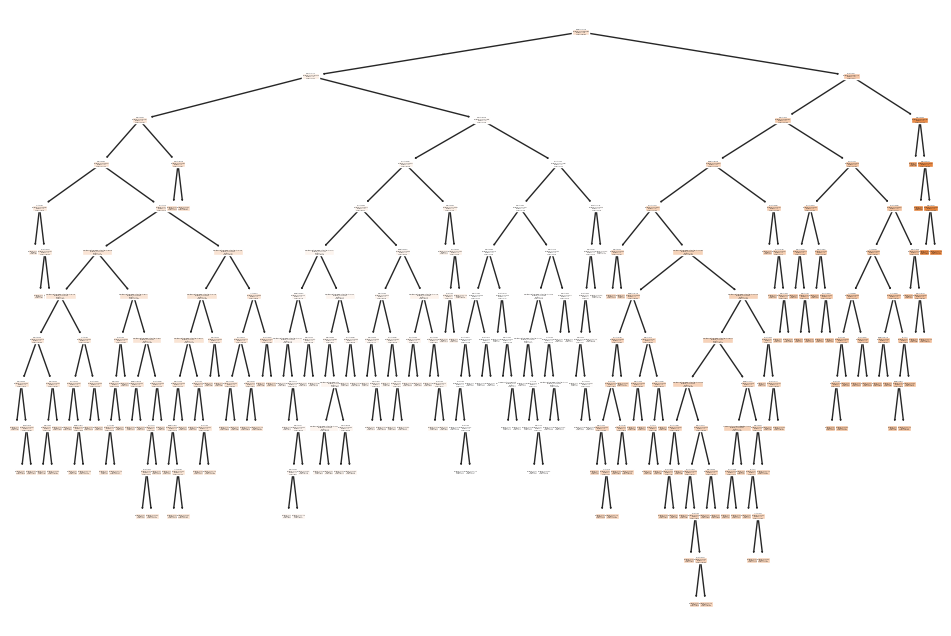

In [127]:
from sklearn.tree import export_text, plot_tree
plt.figure(figsize=(12, 8))
plot_tree(shortwave_estimator, feature_names=X_train_dc.columns, filled=True)
plt.show()

In [128]:
tree_text = export_text(shortwave_estimator, feature_names=list(X_train_dc.columns))
print(tree_text)

|--- DNB <= 144.39
|   |--- SZA <= 71.01
|   |   |--- M6 <= 6.66
|   |   |   |--- M5 <= 5.99
|   |   |   |   |--- I2 <= 6.96
|   |   |   |   |   |--- value: [96.67]
|   |   |   |   |--- I2 >  6.96
|   |   |   |   |   |--- M10 <= 0.31
|   |   |   |   |   |   |--- value: [106.91]
|   |   |   |   |   |--- M10 >  0.31
|   |   |   |   |   |   |--- value: [108.79]
|   |   |   |--- M5 >  5.99
|   |   |   |   |--- M1 <= 7.76
|   |   |   |   |   |--- Shortwave Filtered Rads (Integrated) <= 88.24
|   |   |   |   |   |   |--- Shortwave Filtered Rads (Integrated) <= 87.49
|   |   |   |   |   |   |   |--- M2 <= 8.41
|   |   |   |   |   |   |   |   |--- M3 <= 8.95
|   |   |   |   |   |   |   |   |   |--- value: [119.10]
|   |   |   |   |   |   |   |   |--- M3 >  8.95
|   |   |   |   |   |   |   |   |   |--- RAZ <= 22.50
|   |   |   |   |   |   |   |   |   |   |--- value: [119.25]
|   |   |   |   |   |   |   |   |   |--- RAZ >  22.50
|   |   |   |   |   |   |   |   |   |   |--- value: [119.17]
|   | 

In [111]:
dc_rmse_percent = [0, 0]
tg_range_dc = max(y_test_dc["Shortwave Unfiltered Rads (Integrated)"]) - min(
    y_test_dc["Shortwave Unfiltered Rads (Integrated)"])
dc_rmse_percent[0] = (1.0 - (dc_mse[0] / tg_range_dc)) * 100
tg_range_dc = max(y_test_dc["Longwave Unfiltered Rads (Integrated)"]) - min(
    y_test_dc["Longwave Unfiltered Rads (Integrated)"])
dc_rmse_percent[1] = (1.0 - (dc_mse[1] / tg_range_dc)) * 100
dc_rmse_percent

[99.77767215544363, 74.79745360462779]

In [114]:
dc_scores = cross_val_score(dc_model, X_dc, y_dc, cv=5, scoring="neg_mean_squared_error")
print(f"Cross-validated MSE: {-dc_scores.mean()}", dc_scores)

Cross-validated MSE: 247.82315420342692 [-132.03600097 -296.86980398  -61.83228161 -200.96216447 -547.41551999]


In [40]:
def regression_model(dataset: pd.DataFrame, neurons=100, rf = True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    # X, y = None, None
    base_model = None
    # if just_bands:
    #     X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)",
    #                               'Longwave Filtered Rads (Integrated)', 'Shortwave Filtered Rads (Integrated)']).reset_index(drop=True)
    #     y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
    #                                'Shortwave Filtered Rads (Integrated)',
    #                                'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
    #                                'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
    #                                'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)
    # else:
    X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)",]).reset_index(drop=True)
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                               'Shortwave Filtered Rads (Integrated)',
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    # print(X_train.shape, y_train.shape)

    if rf:
        base_model = RandomForestRegressor(n_estimators=neurons, random_state=42)
    else:
        base_model = LinearRegression()
    regression_model = MultiOutputRegressor(base_model)
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
    rmse = root_mean_squared_error(y_test, y_pred, multioutput='raw_values')
    mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Single MSE"] = mse
    ret["RMSE"] = rmse
    ret["MAE"] = mae
    ret["MAEP"] = mae_percentage

    tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    ret["Shortwave MSPE"] = (1.0 - (rmse[0] / tg_range_sw)) * 100

    tg_range_lw = max(y_test["Longwave Unfiltered Rads (Integrated)"]) - min(y_test["Longwave Unfiltered Rads (Integrated)"])
    ret["Longwave MSPE"] = (1.0 - (rmse[1] / tg_range_lw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    ret["CV RMSE"] = cv_scores
    ret["Model"] = regression_model
    ret["Predictions"] = y_pred
    ret["Y_True"] = y_test

    return ret


In [17]:
dc_res = regression_model(dc_dataset, rf=False)
dc_res

(252, 28) (252, 2)


{'Single MSE': array([7.18311795e-06, 2.22679796e-06]),
 'RMSE': array([0.00268013, 0.00149225]),
 'MAE': array([0.0022058 , 0.00079165]),
 'MAEP': array([99.99741736, 99.99907311]),
 'Shortwave MSPE': 99.99942599045907,
 'Longwave MSPE': 99.97602910607387,
 'CV RMSE': array([-0.02104518, -0.00264005, -0.00165923, -0.00495577, -0.04257407]),
 'Model': MultiOutputRegressor(estimator=LinearRegression()),
 'Predictions': array([[ 60.07372402,  31.72090231],
        [241.72081786,  28.65215641],
        [122.44427002,  29.28049873],
        [192.50314138,  28.07655391],
        [191.0700964 ,  28.27619173],
        [ 60.61478131,  29.28136716],
        [252.71190867,  28.93119221],
        [259.46338197,  28.07657268],
        [192.03072466,  27.94472769],
        [186.77213849,  28.93128343],
        [123.27297042,  32.10570858],
        [ 57.36206926,  28.75659323],
        [124.18740967,  28.93129495],
        [206.79701414,  31.31914155],
        [120.36562168,  28.93143002],
        [

In [ ]:
dc_res = regression_model(dc_dataset, rf=False)
dc_res

In [18]:
land_results = regression_model(land_dataset)
land_results

(2520, 28) (2520, 2)


{'Single MSE': array([6.80083779e-01, 4.57864191e-04]),
 'RMSE': array([0.82467192, 0.02139776]),
 'MAE': array([0.32896628, 0.00335989]),
 'MAEP': array([99.62994657, 99.99622047]),
 'Shortwave MSPE': 99.86365663118637,
 'Longwave MSPE': 99.96061076482901,
 'CV RMSE': array([-10.81237733,  -1.03098084,  -0.57161201,  -5.49470729,
        -12.04600423]),
 'Model': MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42)),
 'Predictions': array([[ 14.16094936,  72.33512048],
        [227.28174896,  82.18492694],
        [ 42.13368775,  93.70701235],
        ...,
        [ 76.13155439,  92.0997664 ],
        [ 10.04044563,  74.37593801],
        [ 45.60200579,  91.84426839]]),
 'Y_True':       Shortwave Unfiltered Rads (Integrated)  \
 2965                               14.061196   
 969                               226.981690   
 1385                               41.788831   
 1233                              150.821594   
 2996                               26.599328   

In [24]:
land_neurons = [regression_model(land_dataset, neurons=n) for n in [10, 25, 50, 100, 125, 150, 200]]

(2520, 28) (2520, 2)
(2520, 28) (2520, 2)
(2520, 28) (2520, 2)
(2520, 28) (2520, 2)
(2520, 28) (2520, 2)
(2520, 28) (2520, 2)
(2520, 28) (2520, 2)


In [26]:
land_10, land_25, land_50, land_100, land_125, land_150, land_200 = land_neurons[0], land_neurons[1], land_neurons[2], land_neurons[3], land_neurons[4], land_neurons[5], land_neurons[6]

In [30]:
land_25

{'Single MSE': array([0.63484544, 0.00072069]),
 'RMSE': array([0.79677189, 0.02684559]),
 'MAE': array([0.32990054, 0.0036583 ]),
 'MAEP': array([99.62890509, 99.99588489]),
 'Shortwave MSPE': 99.86826935634976,
 'Longwave MSPE': 99.95058233510684,
 'CV RMSE': array([ -9.71927479,  -1.11932904,  -0.64442053,  -4.92453424,
        -11.89546493]),
 'Model': MultiOutputRegressor(estimator=RandomForestRegressor(n_estimators=25,
                                                      random_state=42)),
 'Predictions': array([[ 14.14860578,  72.33512051],
        [227.28519209,  82.18492946],
        [ 42.03526489,  93.70701871],
        ...,
        [ 76.15459831,  92.09977549],
        [ 10.1262875 ,  74.37594209],
        [ 45.83091171,  91.84427197]]),
 'Y_True':       Shortwave Unfiltered Rads (Integrated)  \
 2965                               14.061196   
 969                               226.981690   
 1385                               41.788831   
 1233                             

In [19]:
snow_results = regression_model(snow_dataset)
snow_results

(1260, 28) (1260, 2)


{'Single MSE': array([5.06825323e-16, 2.42194690e-15]),
 'RMSE': array([2.25127813e-08, 4.92132798e-08]),
 'MAE': array([8.96449986e-09, 1.51469542e-08]),
 'MAEP': array([99.99618196, 99.99354881]),
 'Shortwave MSPE': 99.70305116394496,
 'Longwave MSPE': 99.94088595058116,
 'CV RMSE': array([-1.76643621e-07, -6.50807558e-08, -8.38785913e-08, -6.37077825e-08,
        -7.16635365e-07]),
 'Model': MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42)),
 'Predictions': array([[8.42961184e-07, 4.15974003e-04],
        [1.46264014e-06, 4.59611276e-04],
        [8.65528571e-07, 4.59611276e-04],
        [1.62220171e-06, 4.77051120e-04],
        [1.62649835e-06, 4.77011899e-04],
        [4.40500473e-07, 4.45303605e-04],
        [7.49966814e-07, 4.79259722e-04],
        [1.29851747e-06, 4.45303605e-04],
        [1.50276650e-06, 4.77201091e-04],
        [1.29789105e-06, 4.90054458e-04],
        [5.19772854e-07, 4.90358315e-04],
        [7.10518474e-07, 4.67347810e-04],
        [7.

In [20]:
cloud_results = regression_model(cloud_dataset)
cloud_results

(336, 28) (336, 2)


{'Single MSE': array([1.10948328e-14, 4.57359021e-15]),
 'RMSE': array([1.05332012e-07, 6.76283240e-08]),
 'MAE': array([1.79349316e-08, 2.40754385e-08]),
 'MAEP': array([99.99292657, 99.99050479]),
 'Shortwave MSPE': 97.46322521425175,
 'Longwave MSPE': 99.92946229963239,
 'CV RMSE': array([-1.00992279e-07, -7.47321613e-08, -5.42767148e-08, -2.25901549e-07,
        -1.82973111e-06]),
 'Model': MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42)),
 'Predictions': array([[7.71738618e-07, 4.87992135e-04],
        [6.23321358e-07, 4.75730762e-04],
        [8.95461178e-07, 5.43166005e-04],
        [9.45693036e-08, 4.94304482e-04],
        [6.00653684e-07, 4.60160434e-04],
        [5.67598464e-07, 4.54758281e-04],
        [4.30276299e-07, 5.02174952e-04],
        [7.72028493e-07, 4.87992135e-04],
        [1.70542888e-06, 5.44418920e-04],
        [3.64264079e-07, 4.60316138e-04],
        [9.60193081e-07, 4.75730762e-04],
        [1.25476603e-06, 5.50633620e-04],
        [8.

In [21]:
clear_results = regression_model(clear_dataset)
clear_results

(588, 28) (588, 2)


{'Single MSE': array([1.04991503e-16, 8.16715313e-16]),
 'RMSE': array([1.02465362e-08, 2.85782315e-08]),
 'MAE': array([7.24195201e-09, 9.37387118e-09]),
 'MAEP': array([99.99727546, 99.9964734 ]),
 'Shortwave MSPE': 99.5287407447082,
 'Longwave MSPE': 99.96678798651205,
 'CV RMSE': array([-2.91525400e-08, -3.16859338e-08, -4.70257565e-08, -7.29014026e-08,
        -1.15103224e-07]),
 'Model': MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42)),
 'Predictions': array([[2.13311940e-06, 4.75668530e-04],
        [1.37807881e-07, 5.48516975e-04],
        [1.84537649e-07, 4.75748690e-04],
        [6.98489111e-08, 5.46681192e-04],
        [3.69526185e-07, 5.45207886e-04],
        [3.16488382e-07, 5.56663788e-04],
        [9.19918463e-08, 5.49890286e-04],
        [2.44730463e-07, 5.41828025e-04],
        [3.67766845e-08, 5.52999477e-04],
        [1.69966619e-07, 5.47382509e-04],
        [7.67242227e-08, 5.35699004e-04],
        [3.67766845e-08, 5.51453415e-04],
        [1.5

In [22]:
clear_dataset.shape, cloud_dataset.shape, snow_dataset.shape

((735, 32), (420, 32), (1575, 32))

In [59]:
def estimator_testing(scene: str, dataset: pd.DataFrame):
    res = {}
    N = [10, 25, 50, 100, 125, 150, 200]
    tests = [regression_model(dataset, neurons=n) for n in N]
    for i in range(len(N)):
        del tests[i]["Model"]
        del tests[i]["Predictions"]
        del tests[i]["Y_True"]
        res[f"{scene}_{N[i]}"] = tests[i]

    return res

In [80]:
def plot_ml_est(results_dict):
    """
    Plots different accuracy metrics against the number of estimators.

    :param results_dict: Dictionary with the format:
                         {
                             num_estimators_1: {
                                 "Single MSE": value,
                                 "RMSE": value,
                                 "MAE": value,
                                 "MAEP": value,
                                 "Shortwave MSPE": value,
                                 "Longwave MSPE": value,
                                 "CV RMSPE": value
                             },
                             num_estimators_2: {...},
                             ...
                         }
    """
    # Extracting number of estimators and metrics
    num_estimators = results_dict.keys()
    # print(num_estimators)
    metrics = ["Single MSE", "RMSE", "MAE", "MAEP", "Shortwave MSPE", "Longwave MSPE", "CV RMSE"]

    # Creating a figure for each metric
    for metric in metrics:
        metric_values = [results_dict[est][metric] for est in num_estimators]

        plt.figure(figsize=(8, 5))
        plt.plot(num_estimators, metric_values, marker='o', linestyle='-')
        plt.xlabel("Number of Estimators")
        plt.ylabel(metric)
        plt.title(f"{metric} vs. Number of Estimators")
        plt.grid(True)
        plt.show()

In [48]:
test = {"test": {"fuck": 101}}
test["test"]["fuck"]

101

In [51]:
snow_est_tests = estimator_testing("snow", snow_dataset)
snow_est_tests

{'snow_10': {'Single MSE': array([3.96874244e-15, 4.69989441e-15]),
  'RMSE': array([6.29979558e-08, 6.85557759e-08]),
  'MAE': array([1.37661923e-08, 1.84326634e-08]),
  'MAEP': array([99.99413685, 99.99214935]),
  'Shortwave MSPE': 99.16904227034262,
  'Longwave MSPE': 99.91765211451877,
  'CV RMSE': array([-1.61344688e-07, -4.94194818e-08, -5.58052641e-08, -6.92440225e-08,
         -7.29568086e-07])},
 'snow_25': {'Single MSE': array([3.52610008e-16, 2.79220286e-15]),
  'RMSE': array([1.87779128e-08, 5.28412988e-08]),
  'MAE': array([8.47380919e-09, 1.66247849e-08]),
  'MAEP': array([99.99639096, 99.99291943]),
  'Shortwave MSPE': 99.75231495117718,
  'Longwave MSPE': 99.93652804356233,
  'CV RMSE': array([-1.43900415e-07, -6.26405072e-08, -9.46543513e-08, -6.46842713e-08,
         -7.40466309e-07])},
 'snow_50': {'Single MSE': array([4.44744978e-16, 2.60254183e-15]),
  'RMSE': array([2.10889776e-08, 5.10151137e-08]),
  'MAE': array([9.23329625e-09, 1.49674348e-08]),
  'MAEP': array

In [58]:
snow_est_tests["snow_10"]

{'Single MSE': array([3.96874244e-15, 4.69989441e-15]),
 'RMSE': array([6.29979558e-08, 6.85557759e-08]),
 'MAE': array([1.37661923e-08, 1.84326634e-08]),
 'MAEP': array([99.99413685, 99.99214935]),
 'Shortwave MSPE': 99.16904227034262,
 'Longwave MSPE': 99.91765211451877,
 'CV RMSE': array([-1.61344688e-07, -4.94194818e-08, -5.58052641e-08, -6.92440225e-08,
        -7.29568086e-07])}

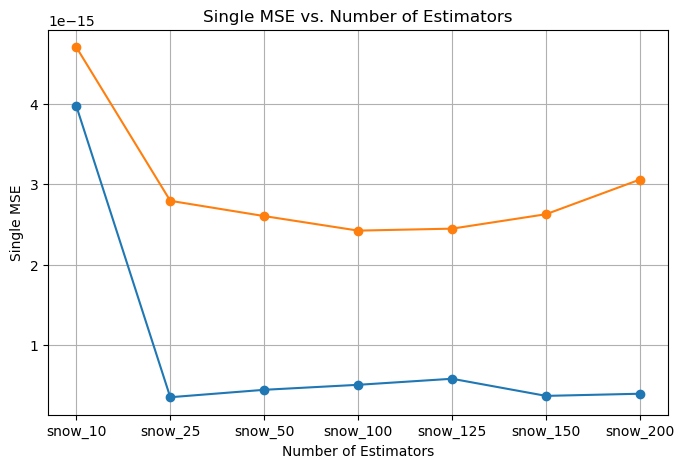

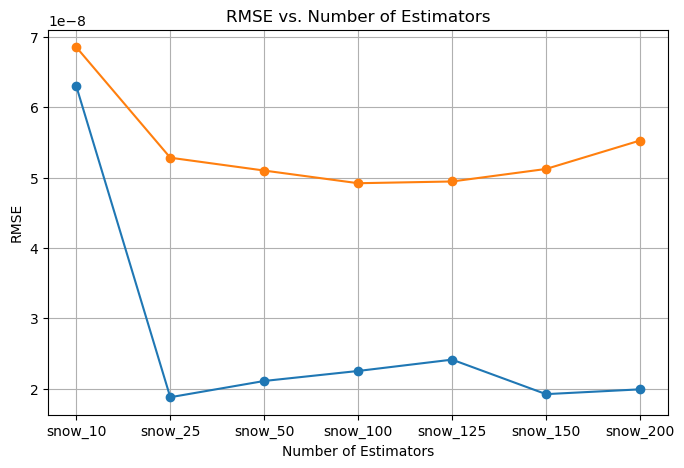

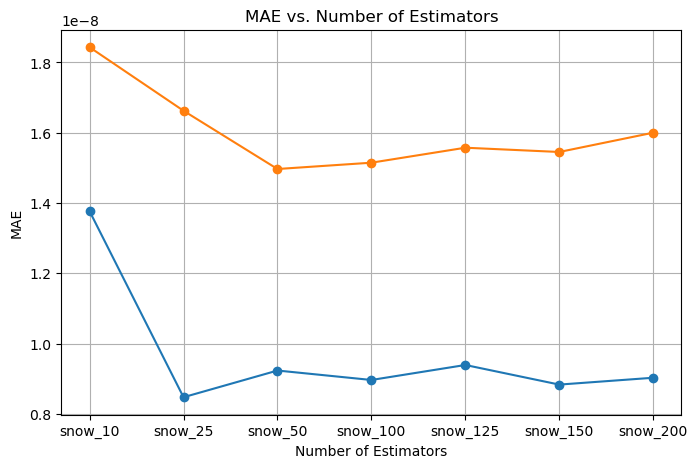

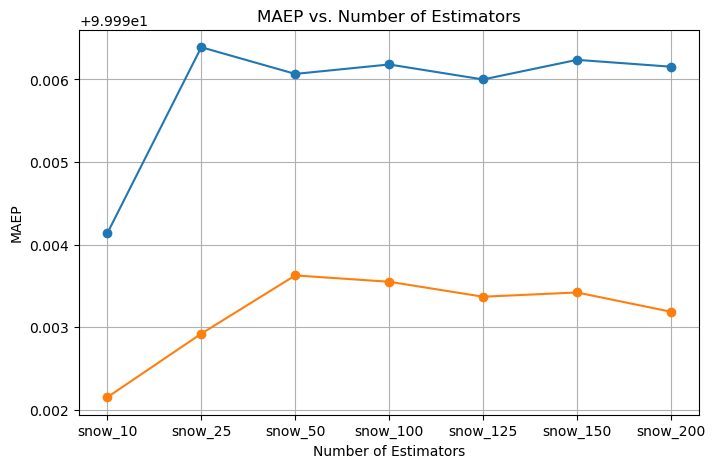

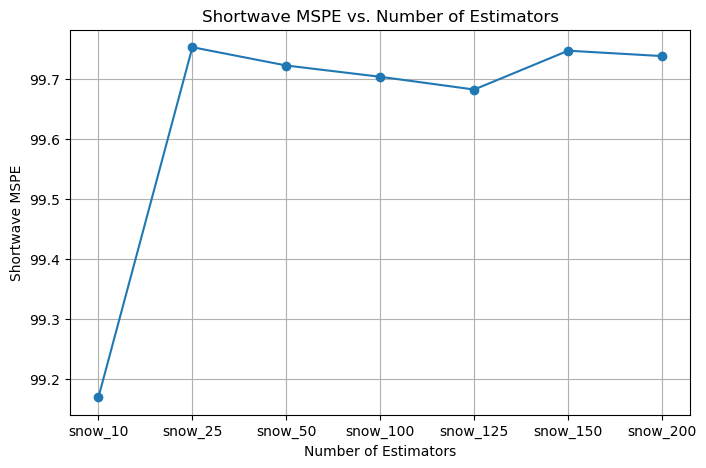

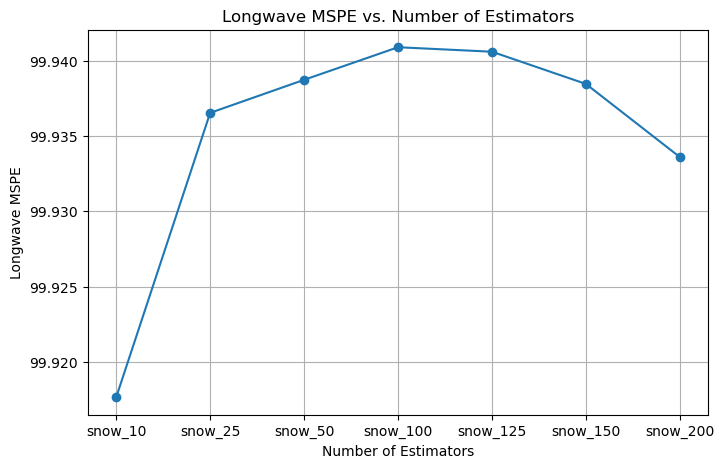

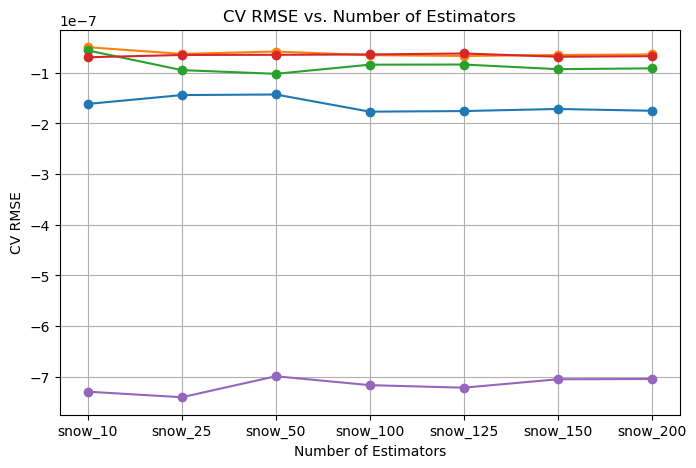

In [81]:
plot_ml_est(snow_est_tests)

In [24]:
sw_mspes = {
    "Land with bands": land_results["Shortwave MSPE"],
    "Snow with bands": snow_results["Shortwave MSPE"],
    "Cloudy Ocean with bands": cloud_results["Shortwave MSPE"],
    "Clear Ocean with bands": clear_results["Shortwave MSPE"],
    "Deep Con clouds with bands": dc_res["Shortwave MSPE"],
}
sw_mspes

{'Land with bands': 99.88756145198919,
 'Snow with bands': 99.85968432880966,
 'Cloudy Ocean with bands': 96.79602647302859,
 'Clear Ocean with bands': 98.33074673207803,
 'Deep Con clouds with bands': 99.99999846157755}

In [25]:
lw_mspes = {
    "Land with bands": land_results["Longwave MSPE"],
    "Snow with bands": snow_results["Longwave MSPE"],
    "Cloudy Ocean with bands": cloud_results["Longwave MSPE"],
    "Clear Ocean with bands": clear_results["Longwave MSPE"],
    "Deep Con clouds with bands": dc_res["Longwave MSPE"],
}
lw_mspes

{'Land with bands': 99.99915715854549,
 'Snow with bands': 99.99902749519755,
 'Cloudy Ocean with bands': 99.99890286949778,
 'Clear Ocean with bands': 99.99962894850125,
 'Deep Con clouds with bands': 99.99996422953078}

In [51]:
1 == True

True

In [28]:
def plot_mspes(mspe, l_or_s=1):
    # Extract keys and values
    scenes = list(mspe.keys())
    mspe_values = list(mspe.values())

    plt.figure(figsize=(8, 6))
    plt.bar(scenes, mspe_values, color='skyblue', edgecolor='black')

    # Set y-axis limit to zoom in on the top
    if l_or_s:
        plt.ylim(95, 100.05)
        wv = "Shortwave"
    else:
        wv = "Longwave"
        plt.ylim(95, 100.05)


    # Labels and Title
    plt.xlabel('Scene')
    plt.ylabel('Accuracy (%)')
    plt.title(f"{wv} Model Accuracy based on Scene and VIIRS Bands")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Optional: Add gridlines for better readability
    plt.show()


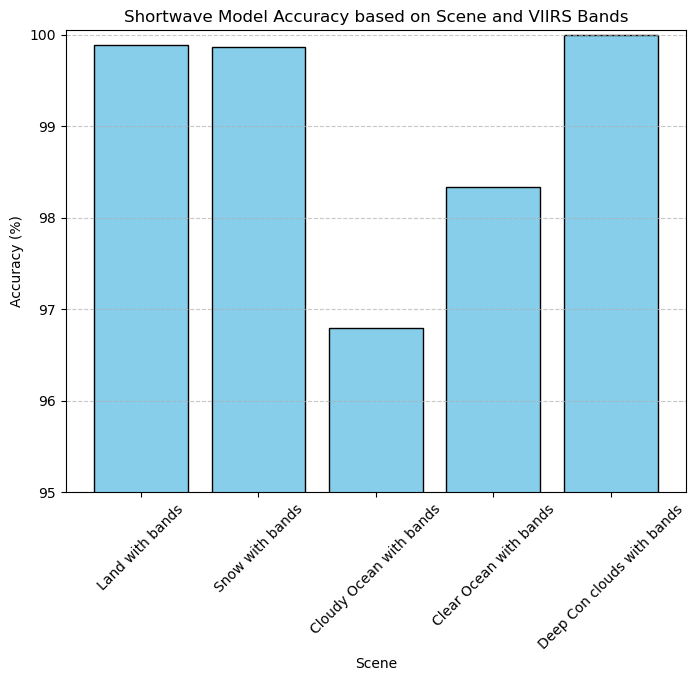

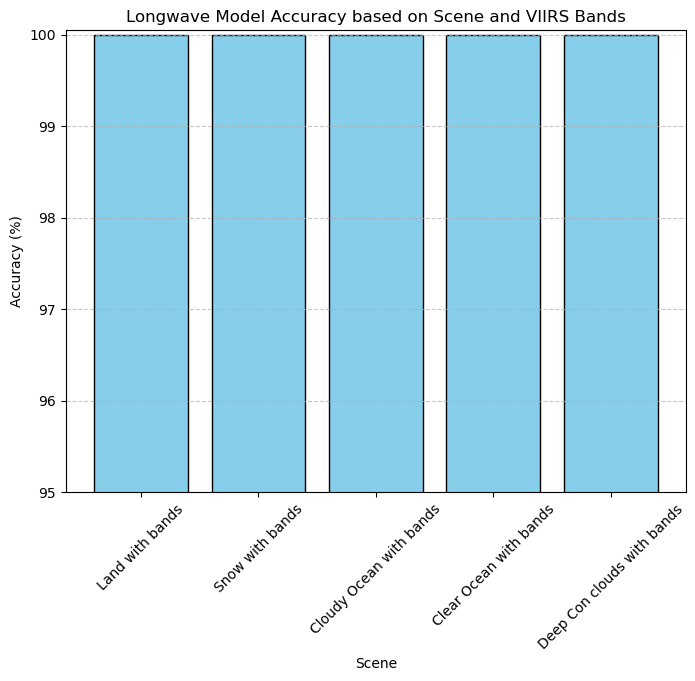

(None, None)

In [29]:
plot_mspes(sw_mspes), plot_mspes(lw_mspes, 0)

In [61]:
np.shape(snow_results["Predictions"]), np.shape(snow_results["Y_True"])

((315, 2), (315, 2))

In [63]:
y_pred_all = [snow_results["Predictions"], [clear_results["Predictions"]], [land_results["Predictions"]], [cloud_results["Predictions"], cloud_res_bands["Predictions"]], [dc_res["Predictions"], dc_res_bands["Predictions"]]]

In [64]:
y_true_all = [[snow_results["Y_True"], snow_res_bands["Y_True"]], [clear_results["Y_True"], clear_res_bands["Predictions"]], [land_results["Y_True"], land_res_bands["Y_True"]], [cloud_results["Y_True"], cloud_res_bands["Y_True"]], [dc_res["Y_True"], dc_res_bands["Y_True"]]]

In [65]:
scenes = ["Snow", "Clear", "Land", "Cloud", "DC"]

In [16]:
t1 = y_pred_all[0][0][:, 0]

NameError: name 'y_pred_all' is not defined

In [82]:
t2 = list(y_true_all[0][0]["Shortwave Unfiltered Rads (Integrated)"])
t2

[8.546243211982511e-07,
 1.4785812511632387e-06,
 8.779460849543544e-07,
 1.6190761990237415e-06,
 1.620144150095379e-06,
 4.3865512093245354e-07,
 7.496527883044016e-07,
 1.2954417698600664e-06,
 1.5176976631726158e-06,
 1.29788173325996e-06,
 5.265974954488215e-07,
 7.055430668258651e-07,
 7.156159802209074e-07,
 8.547138782643332e-07,
 7.378730293240331e-07,
 1.0498870841781146e-06,
 1.027144305957584e-06,
 9.905286671824918e-08,
 2.0778453688897108e-06,
 1.5842805061772874e-06,
 3.649954780758178e-07,
 7.502132711528908e-07,
 1.0308107200711464e-06,
 1.0750319896555749e-06,
 6.120295467780459e-07,
 5.344290620395439e-07,
 7.431166582309303e-07,
 1.6264709555549226e-06,
 1.1502696579411544e-07,
 1.7842389179434628e-06,
 2.078017813618692e-06,
 3.833883414382281e-07,
 1.0507933680641124e-06,
 1.0626541583397853e-06,
 6.672135866241561e-07,
 7.246770073043608e-07,
 1.3842747749512843e-06,
 8.767300813051978e-07,
 9.673309456496524e-07,
 2.894487173831194e-06,
 1.5755275320089713e-06,


In [45]:
wvs = land_data[0].rads[0][0]
wvs.shape

(4000,)

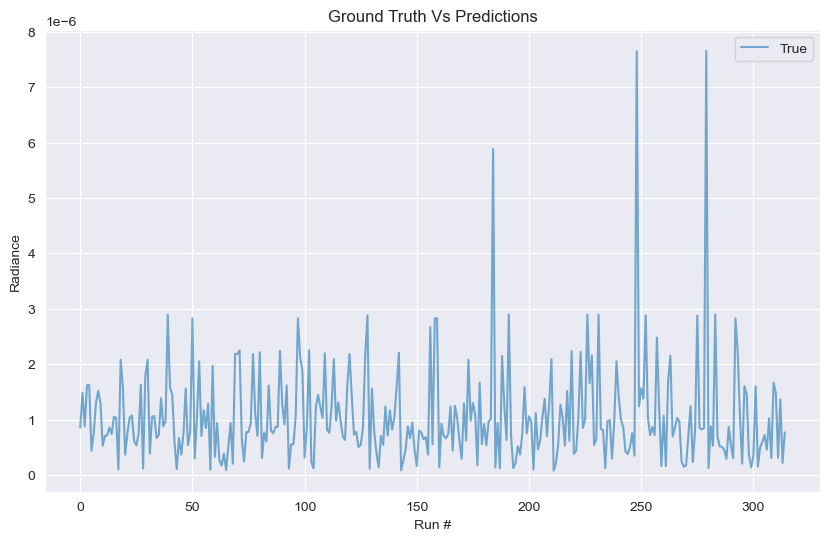

In [96]:
runs_to_plot = 10  # Limit to avoid clutter, or choose specific runs
plt.figure(figsize=(10, 6))

# y_true = describer_df["Shortwave Unfiltered Rads (Integrated)"][i]
# y_pred = model_predictions[i]  # Replace with your predictions per run

plt.plot(t2, label=f'True', alpha=0.6)
# plt.plot(t1, linestyle='--', label=f'Predictions', alpha=0.6)

plt.xlabel('Run #')
plt.ylabel('Radiance')
plt.title('Ground Truth Vs Predictions')
plt.legend(loc='upper right', ncol=2)  # Organize legends to save space
plt.show()

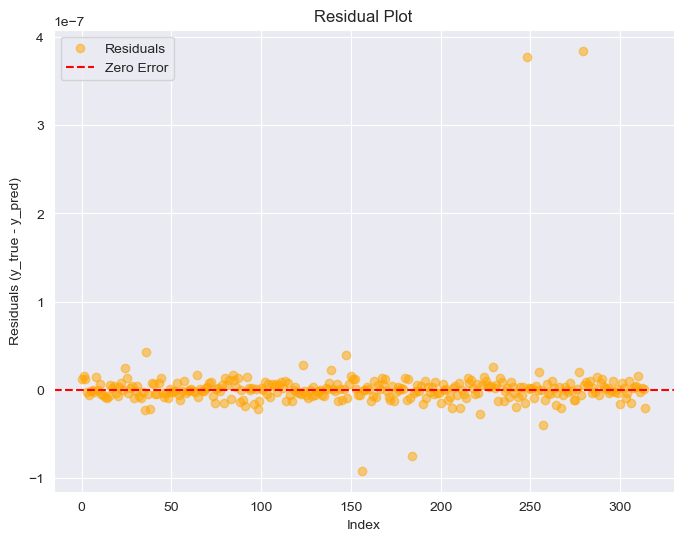

In [87]:
residuals = t2 - t1

plt.figure(figsize=(8, 6))
plt.scatter(range(len(residuals)), residuals, alpha=0.5, color='orange', label='Residuals')
plt.axhline(0, color='red', linestyle='--', label='Zero Error')
plt.xlabel('Index')
plt.ylabel('Residuals (y_true - y_pred)')
plt.title('Residual Plot')
plt.legend()
plt.show()

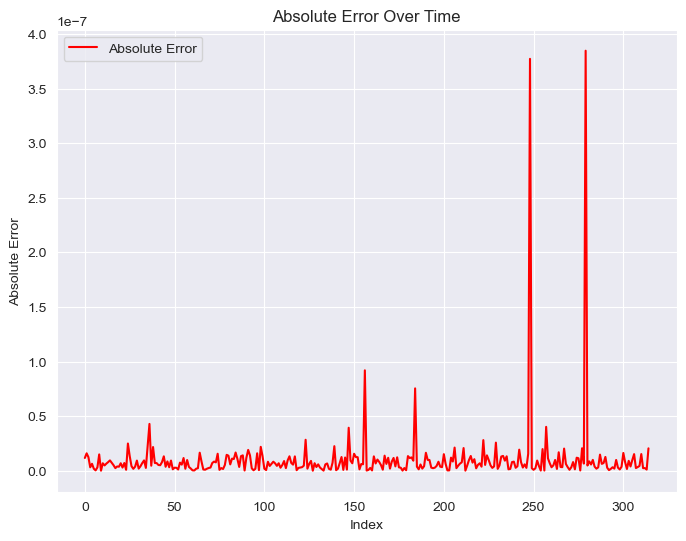

In [92]:
absolute_error = abs(t2 - t1)

plt.figure(figsize=(8, 6))
plt.plot(absolute_error, color='red', label='Absolute Error')
plt.xlabel('Index')
plt.ylabel('Absolute Error')
plt.title('Absolute Error Over Time')
plt.legend()
plt.show()

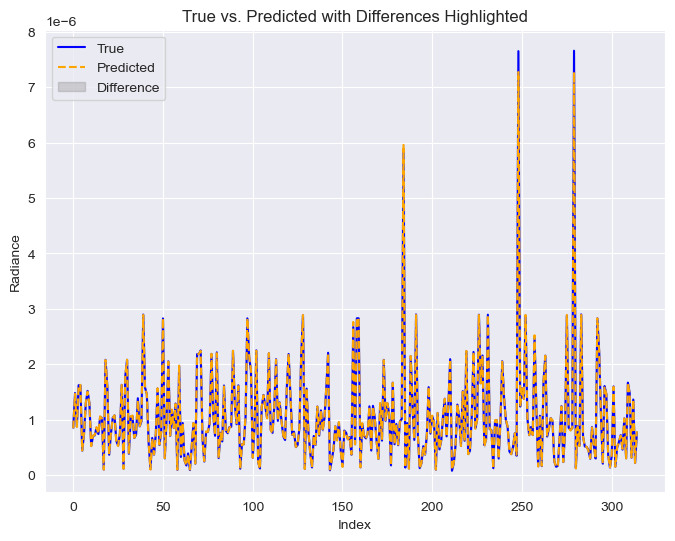

In [93]:
plt.figure(figsize=(8, 6))
plt.plot(t2, label='True', color='blue')
plt.plot(t1, linestyle='--', label='Predicted', color='orange')
plt.fill_between(range(len(t2)), t2, t1, color='gray', alpha=0.3, label='Difference')
plt.xlabel('Index')
plt.ylabel('Radiance')
plt.title('True vs. Predicted with Differences Highlighted')
plt.legend()
plt.show()

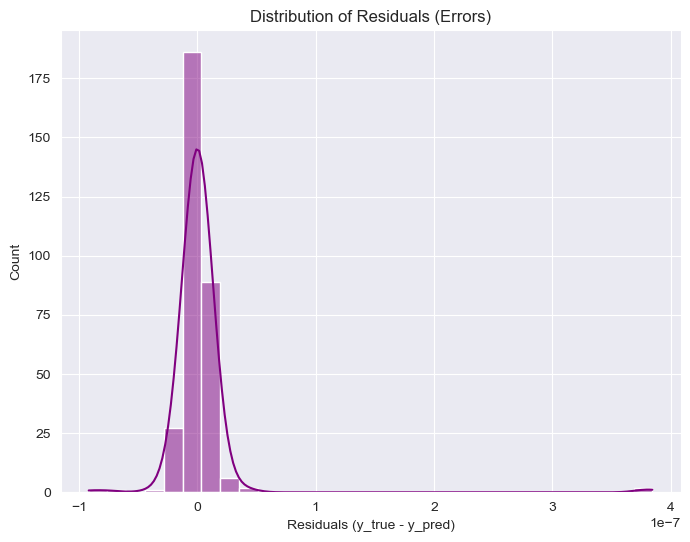

In [95]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30, color='purple')
plt.xlabel('Residuals (y_true - y_pred)')
plt.ylabel('Count')
plt.title('Distribution of Residuals (Errors)')
plt.show()